# Preparación data set

Utilizamos el siguiente dataset: https://www.kaggle.com/datasets/gorochu/complete-imdb-movies-dataset. Este dataset contiene información de 62058 peliculas y series obtenidas por IMBd (Internet Movie Database), con información específica de cada uno. Realizamos una limpieza de los datos siguiendo los siguientes pasos:

1. Conocer la información del dataset
2. Realizar un analisis exploratorio para identificar los problemas a resolver.
3. Aplicar las estrategias de limpieza de datos.

# 1. Conocer la información del dataset

### Las columnas del data set son las siguientes:
- **title**: nombre de la pelicula o la serie. Tipo categórico
- **rating**: clasificación oficial de cada pelicula y serie. Tipo categórico.
- **year**: año de lanzamiento. Tipo numérico.
- **users_rating**: calificación de los usuarios. Tipo numérico
- **votes**: cantidad de votos de cada pelicula y serie. Tipo numérico
- **metascore**: calificación de los críticos de cine y finalmente se asigna la puntuación ponderada. Tipo numérico.
- **img_url**: dirección URL de la portada de cada película. Tipo URL.
- **countries**: país donde se desarrolló la película o la serie. Tipo categórico.
- **languajes**: idioma original de la película o la serie. Tipo categórico.
- **actors**: actores participantes. Tipo categórico.
- **genre**: género de la película o la serie. Tipo categórico.
- **tagline**: frase importante en la producción. Tipo categórico.
- **description**: breve resumen de la producción. Tipo categórico.
- **directors**: directores de la producción. Tipo categórico.
- **runtime**: tiempo de duración. Tipo numérico.
- **imdb_url**: dirección URL de toda la información en la pagina de IMDb. Tipo URL.


# 2. Analisis exploratorio de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importación desde Drive donde se guardó el dataset

In [2]:
Movies = pd.read_csv('movie.csv')

In [3]:
# Guardando el dataset en la variable Movies
Movies = pd.DataFrame(Movies)

In [4]:
# Mostrando los registros del dataset
Movies.head()

,title,rating,year,users_rating,votes,metascore,img_url,countries,languages,actors,genre,tagline,description,directors,runtime,imdb_url
0,A Rainy Day in New York,PG-13,2019.0,6.6,"21,903",44.0,https://m.media-amazon.com/images/M/MV5BODAwZD...,['USA'],['English'],"['Timothée Chalamet', 'Elle Fanning', 'Liev Sc...","['Comedy', 'Romance']",NaN,A young couple arrives in New York for a weeke...,['Woody Allen'],92 min,https://www.imdb.com/title/tt7139936/
1,Murder Manual,18,2020.0,2.4,192,NaN,https://m.media-amazon.com/images/M/MV5BMDI5ZD...,['USA'],['English'],"['Emilia Clarke', 'Hadley Fraser', 'Sylvia Pan...","['Horror', 'Thriller']","When it comes to murder, they wrote the book","Creepy, terrifying chapters from our book of h...","['Michael Escobedo', 'Kelly Hallmark', '4 more...",91 min,https://www.imdb.com/title/tt12384178/
2,Ferris Bueller's Day Off,PG-13,1986.0,7.8,"308,847",61.0,https://m.media-amazon.com/images/M/MV5BMDA0Nj...,['USA'],"['English', 'German']","['Matthew Broderick', 'Alan Ruck', 'Mia Sara',...",['Comedy'],Because life is too beautiful a thing to waste.,A high school wise guy is determined to have a...,['John Hughes'],103 min,https://www.imdb.com/title/tt0091042/
3,Cape Fear,R,1991.0,7.3,"165,628",73.0,https://m.media-amazon.com/images/M/MV5BNjdhNz...,['USA'],['English'],"['Robert De Niro', 'Nick Nolte', 'Jessica Lang...","['Crime', 'Thriller']",There is nothing in the dark that isn't there ...,"A convicted rapist, released from prison after...",['Martin Scorsese'],128 min,https://www.imdb.com/title/tt0101540/
4,Mean Girls,PG-13,2004.0,7.0,"320,492",66.0,https://m.media-amazon.com/images/M/MV5BMjE1MD...,"['USA', 'Canada']","['English', 'German', 'Vietnamese', 'Swahili']","['Lindsay Lohan', 'Rachel McAdams', 'Tina Fey'...",['Comedy'],Survival of the Ruthless,"Cady Heron is a hit with The Plastics, the A-l...",['Mark Waters'],97 min,https://www.imdb.com/title/tt0377092/


Podemos observar que las columnas están bien nombradas, por lo que no hay que hacer corracciones en este aspecto

In [5]:
# Visualizacion del a cantidad de datos y columnas
Movies.shape

(62058, 16)

In [6]:

# Visualización de la información de las columnas
Movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62058 entries, 0 to 62057
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         62058 non-null  object 
 1   rating        41391 non-null  object 
 2   year          62054 non-null  float64
 3   users_rating  62056 non-null  float64
 4   votes         62056 non-null  object 
 5   metascore     9611 non-null   float64
 6   img_url       58913 non-null  object 
 7   countries     62058 non-null  object 
 8   languages     62058 non-null  object 
 9   actors        62058 non-null  object 
 10  genre         62058 non-null  object 
 11  tagline       38302 non-null  object 
 12  description   58416 non-null  object 
 13  directors     61622 non-null  object 
 14  runtime       49893 non-null  object 
 15  imdb_url      62058 non-null  object 
dtypes: float64(3), object(13)
memory usage: 7.6+ MB


Podemos observar algunos de los problemas que tenemos, algunas columnas que deberían ser de tipo numérico (float64) son de tipo categórico (object); rating, votes y runtime. También que no en todas las columnas hay datos nulos.

 Usamos el método **describe()** para obtener datos estadísticos de las columnas de tipo numérico.

In [7]:
# Visualizamos los datos estadísticos de las columnas de tipo numérico
Movies.describe()

,year,users_rating,metascore
count,62054.000000,62056.000000,9611.000000
mean,1988.081445,5.814105,52.611799
std,29.814372,1.352186,17.789919
min,1903.000000,1.000000,1.000000
25%,1965.000000,5.000000,40.000000
50%,2001.000000,6.000000,53.000000
75%,2012.000000,6.700000,65.000000
max,2020.000000,10.000000,100.000000


Como se observa con la función describe, solo nos muestra 3 columnas que se refieren a datos númericos lo primero que hay que hacer es identificar aquellas columnas de las 16, cuales datos son númericos ademas de estos 3. No vemos información extraña en las columnas year, users:rating y metascore

In [8]:
# Visualicación de datos adicionales de los valores de tipo categórico sin contar valores nulos

Movies.describe(include='O').T

,count,unique,top,freq
title,62058,56769,Homecoming,10
rating,41391,30,R,11368
votes,62056,11627,6,1306
img_url,58913,58067,https://m.media-amazon.com/images/G/01/imdb/im...,789
countries,62058,1445,['USA'],55110
languages,62058,1296,['English'],55728
actors,62058,61543,[],429
genre,62058,3129,['Drama'],8037
tagline,38302,38110,Based on a true story.,9
description,58416,58345,The story of,12


In [9]:
# Mirando los valores unicos en la columna votes
Movies["votes"].unique()

array(['21,903', '192', '308,847', ..., '502,355', '383,246', '216,359'],
      shape=(11628,), dtype=object)

Se observa que hay un problema con las dos columnas debido a que tienen caracteres especificos que no concuerdan con el tipo de dato que debería ser


1.   Para la columna "runtime" está el caracter "min" al lado del tiempo que transcurre la pelicula.
2.   Los elementos de la columna "votes" no es tomado como valor numerico debido a caracteres especiales



In [10]:
# Mirando los valores unicos en la columna rating
Movies['rating'].unique()

array(['PG-13', '18', 'R', 'G', 'PG', nan, 'TV-MA', 'Unrated',
       'Not Rated', 'Passed', 'Approved', 'TV-14', 'UA', 'GP', 'TV-PG',
       'M', 'X', 'TV-G', 'NC-17', 'M/PG', 'TV-Y', 'C', 'TV-Y7', 'AO', 'U',
       'Open', 'E', '(Banned)', 'A', 'TV-13', 'All'], dtype=object)

## Resultados del análisis exploratorio:
- Existen valores nulos en todas las columnas
- Para la columna "runtime" está el caracter "min" al lado del tiempo que transcurre la pelicula.
- Los elementos de la columna "votes" no es tomado como valor numerico debido a caracteres especiales.
- Se pueden unificar las categorias de las películas y series de la columna "rating".


# Con la infomación anterior se puede hacer la limpiaza de datos

### Primero se realizará una copia del documento orginal para no modificar el original en caso de que se cometa un error


In [11]:
MoviesCopy=Movies.copy()

# Valores nulos

## Columna "votes"
Ver el tipo de dato y los primeros datos para identificar el problema de escritura para el tipo de datos

In [12]:
MoviesCopy["votes"].dtype

dtype('O')

Se obseva que el problema en el tipo de datos se refiere a que hay una coma en los datos que no permite entender la columna como un tipo numerico

Se cambia el tipo de datos como un string para poder utilizar la función replace y apply para eliminar un caracter del string

In [13]:
MoviesCopy['votes'] = MoviesCopy['votes'].astype(str)

Se reemplaza la coma por simplemente nada señalado como ' '

In [14]:
MoviesCopy["votes"]=MoviesCopy['votes'].apply(lambda x: x.replace(',', ''))

Cuando se verifican los datos de la columna se observa que son unicamente numericos

In [15]:
MoviesCopy["votes"]

0         21903
1           192
2        308847
3        165628
4        320492
          ...  
62053        81
62054        13
62055         6
62056        13
62057       102
Name: votes, Length: 62058, dtype: object

Ahora es posible reemplazar el tipo de dato como un float64

In [16]:
MoviesCopy['votes'] = MoviesCopy['votes'].astype(np.float64)

Se verifica el cambio de tipo de variable

In [17]:
MoviesCopy['votes'].dtype

dtype('float64')

Verificando nuevamente que con la función describe se realiza la media, el minimo, los cuartiles, etc, con la columna "votes"

In [18]:
MoviesCopy.describe()

,year,users_rating,votes,metascore
count,62054.000000,62056.000000,6.205600e+04,9611.000000
mean,1988.081445,5.814105,1.082188e+04,52.611799
std,29.814372,1.352186,5.982743e+04,17.789919
min,1903.000000,1.000000,5.000000e+00,1.000000
25%,1965.000000,5.000000,2.600000e+01,40.000000
50%,2001.000000,6.000000,1.340000e+02,53.000000
75%,2012.000000,6.700000,9.460000e+02,65.000000
max,2020.000000,10.000000,2.250362e+06,100.000000


Se realiza lo mismo con la columna "runtime" eliminando la cadena "min" para obetner más información acerca de la duración de las peliculas

In [19]:
MoviesCopy['runtime'] = MoviesCopy['runtime'].astype(str)

In [20]:
MoviesCopy["runtime"]=MoviesCopy['runtime'].apply(lambda x: x.replace('min', ''))

In [21]:
MoviesCopy["runtime"]=MoviesCopy['runtime'].apply(lambda x: x.replace(',', ''))

In [22]:
MoviesCopy['runtime']

0         92 
1         91 
2        103 
3        128 
4         97 
         ... 
62053     61 
62054     nan
62055     54 
62056    105 
62057     86 
Name: runtime, Length: 62058, dtype: object

In [23]:
MoviesCopy['runtime']=MoviesCopy['runtime'].astype(np.float64)

In [24]:
MoviesCopy.describe()

,year,users_rating,votes,metascore,runtime
count,62054.000000,62056.000000,6.205600e+04,9611.000000,49893.000000
mean,1988.081445,5.814105,1.082188e+04,52.611799,90.175355
std,29.814372,1.352186,5.982743e+04,17.789919,23.971402
min,1903.000000,1.000000,5.000000e+00,1.000000,1.000000
25%,1965.000000,5.000000,2.600000e+01,40.000000,79.000000
50%,2001.000000,6.000000,1.340000e+02,53.000000,90.000000
75%,2012.000000,6.700000,9.460000e+02,65.000000,99.000000
max,2020.000000,10.000000,2.250362e+06,100.000000,1500.000000


Ahora es necesario arreglar el titulo de "runtime" especificando que estan en minutos

In [25]:
MoviesCopy=MoviesCopy.rename(columns={'runtime':'runtime(min)'})

In [26]:
MoviesCopy.describe()

,year,users_rating,votes,metascore,runtime(min)
count,62054.000000,62056.000000,6.205600e+04,9611.000000,49893.000000
mean,1988.081445,5.814105,1.082188e+04,52.611799,90.175355
std,29.814372,1.352186,5.982743e+04,17.789919,23.971402
min,1903.000000,1.000000,5.000000e+00,1.000000,1.000000
25%,1965.000000,5.000000,2.600000e+01,40.000000,79.000000
50%,2001.000000,6.000000,1.340000e+02,53.000000,90.000000
75%,2012.000000,6.700000,9.460000e+02,65.000000,99.000000
max,2020.000000,10.000000,2.250362e+06,100.000000,1500.000000


# Visualizamos dropbox para poder observar más información de algunas columnas con irregularidades

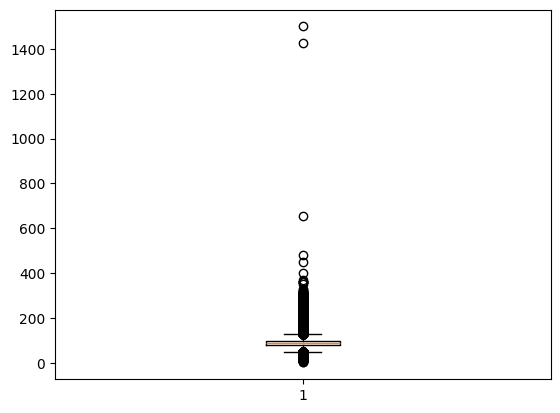

In [27]:
runtime=MoviesCopy['runtime(min)'].dropna()
votes=MoviesCopy['votes'].dropna()
metascore=MoviesCopy['metascore'].dropna()
rate=MoviesCopy['users_rating'].dropna()
year=MoviesCopy['year'].dropna()

plt.boxplot([runtime])
plt.show()

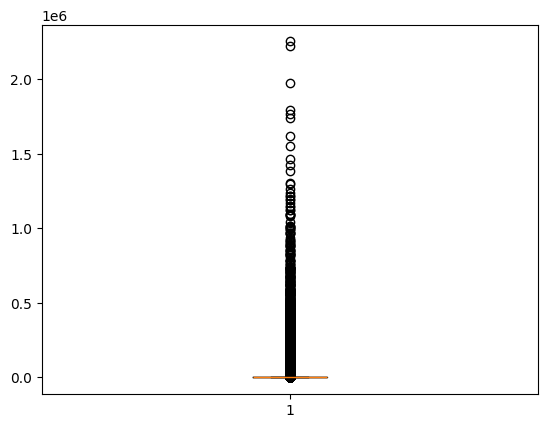

In [28]:
plt.boxplot([votes])
plt.show()

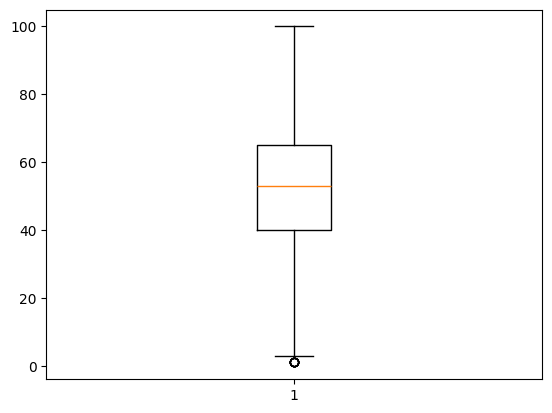

In [29]:
plt.boxplot([metascore])
plt.show()

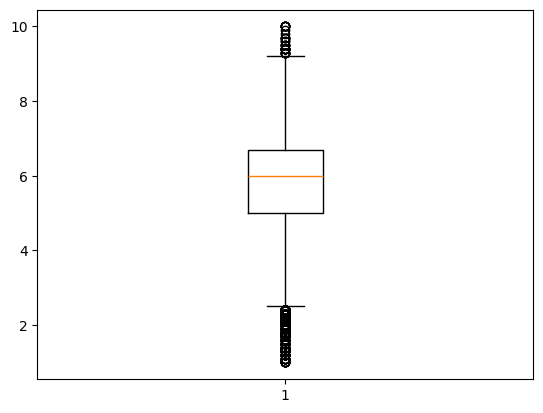

In [30]:
plt.boxplot([rate])
plt.show()

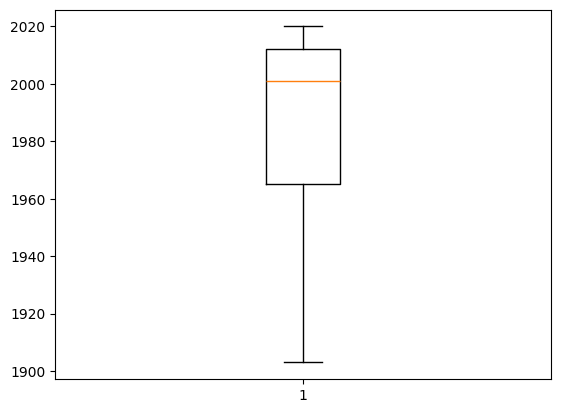

In [31]:
plt.boxplot([year])
plt.show()

##Analisis de gráficas
Despues de observar los boxplot para las 5 columnas del dataset es evidente en las gráficas que hay 2 variables que presentan una gran cantidad de outliers y es necesario arreglar el comportamiento para obtener mejores resultados de la descripcion de la variable.

#Analisis adicional

Se realizará un analisis de la cantidad de elementos vacios que hay en el dataset para seguir conformando la información a arreglar

In [32]:
MoviesCopy.isna().sum()

title               0
rating          20667
year                4
users_rating        2
votes               2
metascore       52447
img_url          3145
countries           0
languages           0
actors              0
genre               0
tagline         23756
description      3642
directors         436
runtime(min)    12165
imdb_url            0
dtype: int64

Vemos que podemos eliminar los datos nulos de las columnas year, users_rating y votes, ya que representan 4, 2 y 2 datos respectivamente, por lo que no afectará nuestro análisis

In [33]:
# Eliminando las filas de year
MoviesCopy = MoviesCopy[MoviesCopy['year'].notnull()]
MoviesCopy = MoviesCopy.reset_index() # Es sumamente importante resetear el índice de los datos para mantener el orden de enumeración.
MoviesCopy.drop('index', axis=1, inplace=True)

Movie_aux = MoviesCopy.copy()


MoviesCopy.isna().sum()

title               0
rating          20663
year                0
users_rating        2
votes               2
metascore       52443
img_url          3145
countries           0
languages           0
actors              0
genre               0
tagline         23753
description      3641
directors         436
runtime(min)    12163
imdb_url            0
dtype: int64

In [34]:
# Eliminando las filas de votes
MoviesCopy = MoviesCopy[MoviesCopy['votes'].notnull()]
MoviesCopy = MoviesCopy.reset_index() # Es sumamente importante resetear el índice de los datos para mantener el orden de enumeración.
MoviesCopy.drop('index', axis=1, inplace=True)

Movie_aux = MoviesCopy.copy()


MoviesCopy.isna().sum()

title               0
rating          20663
year                0
users_rating        0
votes               0
metascore       52441
img_url          3145
countries           0
languages           0
actors              0
genre               0
tagline         23752
description      3641
directors         436
runtime(min)    12163
imdb_url            0
dtype: int64

In [35]:
# Eliminando las filas de users_rating
MoviesCopy = MoviesCopy[MoviesCopy['users_rating'].notnull()]
MoviesCopy = MoviesCopy.reset_index() # Es sumamente importante resetear el índice de los datos para mantener el orden de enumeración.
MoviesCopy.drop('index', axis=1, inplace=True)

Movie_aux = MoviesCopy.copy()


MoviesCopy.isna().sum()

title               0
rating          20663
year                0
users_rating        0
votes               0
metascore       52441
img_url          3145
countries           0
languages           0
actors              0
genre               0
tagline         23752
description      3641
directors         436
runtime(min)    12163
imdb_url            0
dtype: int64

# Realizando histogramas para elegir una estrategia de imputación adecuada.

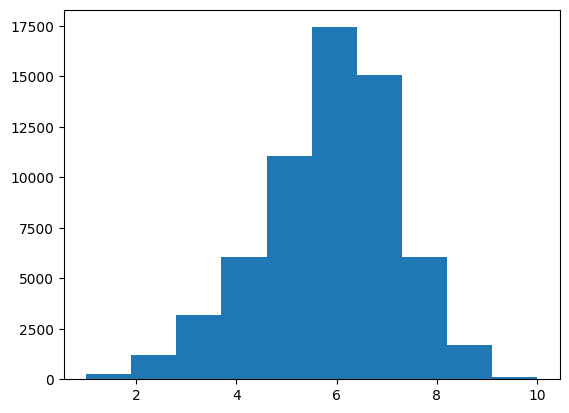

In [36]:
plt.hist(rate)
plt.show()

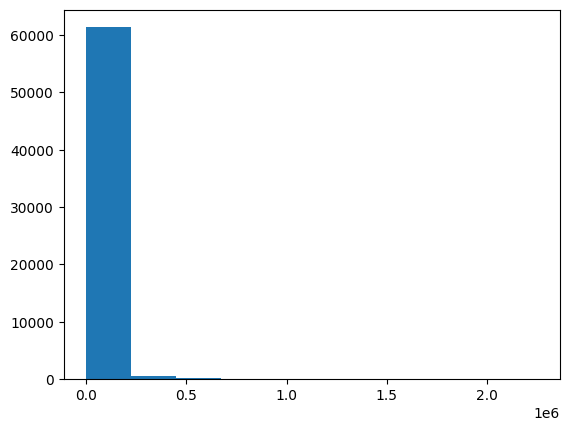

In [37]:
plt.hist(votes)
plt.show()

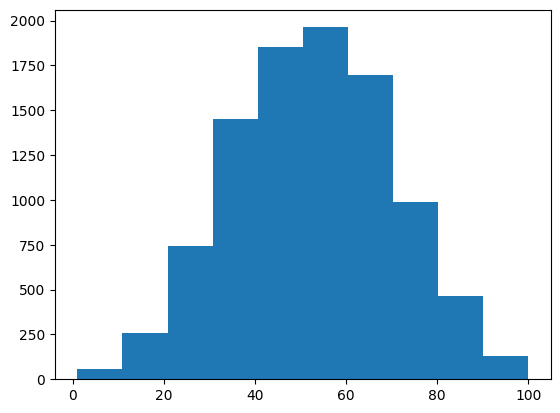

In [38]:
plt.hist(metascore)
plt.show()

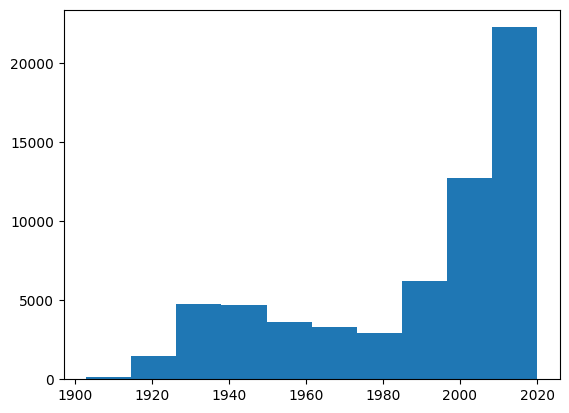

In [39]:
plt.hist(year)
plt.show()

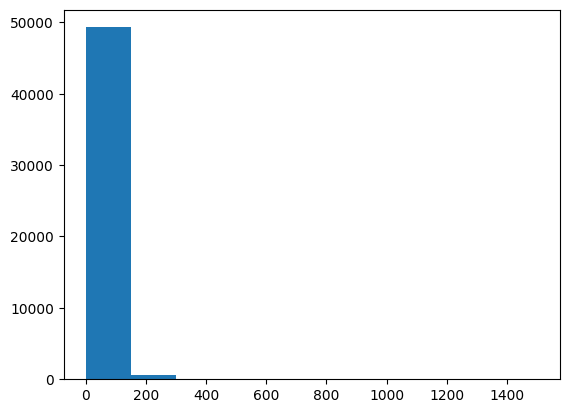

In [40]:
plt.hist(runtime)
plt.show()

Estas gráficas nos indican que para la columna Runtime(min) la distribución de sus datos no parece ser homogénea por lo que es conveniente utilizar la mediana como estrategia de imputación de sus valores nulos.

In [41]:
# Usamos el método median() para obtener la mediana o promedio de los valores de cada columna.
Runtime_median = runtime.median()

# Con el método fillna() reemplazamos los valores nulos de cada columna por la mediana.
MoviesCopy.fillna({ 'runtime(min)': Runtime_median }, inplace=True)

# Verificamos el número total de valores nulos de cada columna del dataset.
MoviesCopy.isna().sum()

title               0
rating          20663
year                0
users_rating        0
votes               0
metascore       52441
img_url          3145
countries           0
languages           0
actors              0
genre               0
tagline         23752
description      3641
directors         436
runtime(min)        0
imdb_url            0
dtype: int64

## Columna metascore

Podemos ver que la columna metascore tiene 52441 datos nulos, representando una gran cantidad para nuestro dataset.

Pudimos observar que la diferencia entre 'users_rating' y 'metascore' es que se puede multiplicar por 10 'users_rating' y es muy parecido el valor al que se presenta en 'metascore'

In [42]:
# Importamos una libreria que podría ser de utilidad
from pickle import TRUE

# Creamos la variable auxx_Movies para realizar la multiplicación de users_rating y pasamos solamente los datos no nulos
# para observar si hay una gran diferencia entre ambas columnas
auxx_Movies=MoviesCopy
auxx_Movies=auxx_Movies[MoviesCopy['metascore'].notnull()]
auxx_Movies=auxx_Movies.reset_index() # Es sumamente importante resetear el índice de los datos para mantener el orden de enumeración.
auxx_Movies.drop('index', axis=1, inplace=True)
auxx_Movies['users_rating'] *= 10

auxx_Movies

,title,rating,year,users_rating,votes,metascore,img_url,countries,languages,actors,genre,tagline,description,directors,runtime(min),imdb_url
0,A Rainy Day in New York,PG-13,2019.0,66.0,21903.0,44.0,https://m.media-amazon.com/images/M/MV5BODAwZD...,['USA'],['English'],"['Timothée Chalamet', 'Elle Fanning', 'Liev Sc...","['Comedy', 'Romance']",NaN,A young couple arrives in New York for a weeke...,['Woody Allen'],92.0,https://www.imdb.com/title/tt7139936/
1,Ferris Bueller's Day Off,PG-13,1986.0,78.0,308847.0,61.0,https://m.media-amazon.com/images/M/MV5BMDA0Nj...,['USA'],"['English', 'German']","['Matthew Broderick', 'Alan Ruck', 'Mia Sara',...",['Comedy'],Because life is too beautiful a thing to waste.,A high school wise guy is determined to have a...,['John Hughes'],103.0,https://www.imdb.com/title/tt0091042/
2,Cape Fear,R,1991.0,73.0,165628.0,73.0,https://m.media-amazon.com/images/M/MV5BNjdhNz...,['USA'],['English'],"['Robert De Niro', 'Nick Nolte', 'Jessica Lang...","['Crime', 'Thriller']",There is nothing in the dark that isn't there ...,"A convicted rapist, released from prison after...",['Martin Scorsese'],128.0,https://www.imdb.com/title/tt0101540/
3,Mean Girls,PG-13,2004.0,70.0,320492.0,66.0,https://m.media-amazon.com/images/M/MV5BMjE1MD...,"['USA', 'Canada']","['English', 'German', 'Vietnamese', 'Swahili']","['Lindsay Lohan', 'Rachel McAdams', 'Tina Fey'...",['Comedy'],Survival of the Ruthless,"Cady Heron is a hit with The Plastics, the A-l...",['Mark Waters'],97.0,https://www.imdb.com/title/tt0377092/
4,Gretel & Hansel,PG-13,2020.0,53.0,15051.0,64.0,https://m.media-amazon.com/images/M/MV5BOTIyYW...,"['Canada', 'Ireland', 'USA', 'South Africa']",['English'],"['Sophia Lillis', 'Samuel Leakey', 'Alice Krig...","['Fantasy', 'Horror', 'Mystery', 'Thriller']",Follow the crumbs.,A long time ago in a distant fairy tale countr...,['Oz Perkins'],87.0,https://www.imdb.com/title/tt9086228/
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9606,Motherland,NaN,2009.0,45.0,13.0,42.0,https://m.media-amazon.com/images/M/MV5BYTkyZW...,['USA'],['English'],"['Françoise Yip', 'Byron Mann', 'Kenneth Tsang...",['Drama'],NaN,"After a long absence abroad, young Asian Ameri...",['Doris Yeung'],90.0,https://www.imdb.com/title/tt1331023/
9607,Cupid's Mistake,Not Rated,2001.0,64.0,47.0,18.0,https://m.media-amazon.com/images/M/MV5BMTk3MD...,['USA'],['English'],"['Everardo Gil', 'Susan Petry', 'Toya Cho', 'K...",[],NaN,A refreshing and humorous take on dating in Lo...,['Young Man Kang'],70.0,https://www.imdb.com/title/tt0213582/
9608,Daydream Believer,NaN,2001.0,59.0,33.0,53.0,https://m.media-amazon.com/images/M/MV5BYWJiNT...,['USA'],['English'],"['Patrick Barnes', 'Andrew Hernin', 'Sybil Kem...",[],NaN,An aspiring actress impulsively leaves her sma...,['Debra Eisenstadt'],79.0,https://www.imdb.com/title/tt0276050/
9609,Don't Ask Don't Tell,Not Rated,2002.0,41.0,113.0,33.0,https://m.media-amazon.com/images/M/MV5BMTUwMj...,['USA'],['English'],"['Lloyd Floyd', 'Erik Frandsen', 'Darby McKinn...","['Comedy', 'Fantasy', 'Sci-Fi']",NaN,"""What's Up Tiger Lily?"" meets mystery science ...",['Doug Miles'],75.0,https://www.imdb.com/title/tt0335057/


In [43]:
Selected_columns=auxx_Movies[['users_rating', 'metascore']]
numeric_columns=Selected_columns[['users_rating', 'metascore']]
numeric_columns.corr()

,users_rating,metascore
users_rating,1.000000,0.676801
metascore,0.676801,1.000000


In [44]:
# multiplicando users_rating por 10 y restando ambas columnas
auxx_Movies['diferencia']=(auxx_Movies['users_rating']-auxx_Movies['metascore'])

#Obtenemos el promedio de esta nueva columna 'diferencia'
media_dif=auxx_Movies['diferencia'].mean()
media_dif

np.float64(9.481427530954115)

Podemos visualizar que la diferencia es de 9 puntos, por lo que podemos hacer el procedimiento para los valores nulos de la columa **metascore**

In [45]:
NewMetascore=((MoviesCopy['users_rating'])*10)-media_dif
MoviesCopy['metascore'].fillna(NewMetascore, inplace=True)
MoviesCopy

/tmp/ipykernel_19015/2257537224.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  MoviesCopy['metascore'].fillna(NewMetascore, inplace=True)


,title,rating,year,users_rating,votes,metascore,img_url,countries,languages,actors,genre,tagline,description,directors,runtime(min),imdb_url
0,A Rainy Day in New York,PG-13,2019.0,6.6,21903.0,44.000000,https://m.media-amazon.com/images/M/MV5BODAwZD...,['USA'],['English'],"['Timothée Chalamet', 'Elle Fanning', 'Liev Sc...","['Comedy', 'Romance']",NaN,A young couple arrives in New York for a weeke...,['Woody Allen'],92.0,https://www.imdb.com/title/tt7139936/
1,Murder Manual,18,2020.0,2.4,192.0,14.518572,https://m.media-amazon.com/images/M/MV5BMDI5ZD...,['USA'],['English'],"['Emilia Clarke', 'Hadley Fraser', 'Sylvia Pan...","['Horror', 'Thriller']","When it comes to murder, they wrote the book","Creepy, terrifying chapters from our book of h...","['Michael Escobedo', 'Kelly Hallmark', '4 more...",91.0,https://www.imdb.com/title/tt12384178/
2,Ferris Bueller's Day Off,PG-13,1986.0,7.8,308847.0,61.000000,https://m.media-amazon.com/images/M/MV5BMDA0Nj...,['USA'],"['English', 'German']","['Matthew Broderick', 'Alan Ruck', 'Mia Sara',...",['Comedy'],Because life is too beautiful a thing to waste.,A high school wise guy is determined to have a...,['John Hughes'],103.0,https://www.imdb.com/title/tt0091042/
3,Cape Fear,R,1991.0,7.3,165628.0,73.000000,https://m.media-amazon.com/images/M/MV5BNjdhNz...,['USA'],['English'],"['Robert De Niro', 'Nick Nolte', 'Jessica Lang...","['Crime', 'Thriller']",There is nothing in the dark that isn't there ...,"A convicted rapist, released from prison after...",['Martin Scorsese'],128.0,https://www.imdb.com/title/tt0101540/
4,Mean Girls,PG-13,2004.0,7.0,320492.0,66.000000,https://m.media-amazon.com/images/M/MV5BMjE1MD...,"['USA', 'Canada']","['English', 'German', 'Vietnamese', 'Swahili']","['Lindsay Lohan', 'Rachel McAdams', 'Tina Fey'...",['Comedy'],Survival of the Ruthless,"Cady Heron is a hit with The Plastics, the A-l...",['Mark Waters'],97.0,https://www.imdb.com/title/tt0377092/
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62047,The Fighting Vigilantes,Not Rated,1947.0,6.3,81.0,53.518572,https://m.media-amazon.com/images/M/MV5BMzlmNG...,['USA'],['English'],"['Lash La Rue', 'Al St. John', 'Jennifer Holt'...","['Action', 'Adventure', 'Western']","""LASH"" LEADS VIGILANTE VENGEANCE! (original po...",Taylor's men are robbing incoming supply wagon...,['Ray Taylor'],61.0,https://www.imdb.com/title/tt0039380/
62048,The Final Equation,NaN,2009.0,6.9,13.0,59.518572,https://m.media-amazon.com/images/M/MV5BMWQxMz...,['USA'],['English'],"['Robert Harriell', 'Cassandra Cooke', 'Paul W...","['Sci-Fi', 'Thriller']",Einstein's Dream has just become Jack Smith's ...,"Through a series of String equations, physicis...",['Daniel Ulysses Abella'],90.0,https://www.imdb.com/title/tt0475272/
62049,Law of the West,NaN,1949.0,6.2,6.0,52.518572,https://m.media-amazon.com/images/M/MV5BOTg4OW...,['USA'],['English'],"['Johnny Mack Brown', 'Max Terhune', 'Bill Ken...",['Western'],Range Pirates Walk The Plank... when Johnny's ...,"With the railroad coming, Nixon is after the r...",['Ray Taylor'],54.0,https://www.imdb.com/title/tt0041584/
62050,Devil's Point,NaN,2014.0,6.0,13.0,50.518572,https://m.media-amazon.com/images/M/MV5BYzc0ZD...,['USA'],['English'],"['Charlisa Anderson', 'Emily Bergmann', 'Jerem...","['Horror', 'Thriller']",NaN,The mysterious area of woods known to the loca...,['William Chaffin'],105.0,https://www.imdb.com/title/tt3763854/


In [46]:
Selected_columns=MoviesCopy[['users_rating', 'metascore']]
numeric_columns=Selected_columns[['users_rating', 'metascore']]
numeric_columns.corr()

,users_rating,metascore
users_rating,1.000000,0.935125
metascore,0.935125,1.000000


In [47]:
#Realizando otra visualización de los datos nulos de todas las columnas
MoviesCopy.isna().sum()

title               0
rating          20663
year                0
users_rating        0
votes               0
metascore           0
img_url          3145
countries           0
languages           0
actors              0
genre               0
tagline         23752
description      3641
directors         436
runtime(min)        0
imdb_url            0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

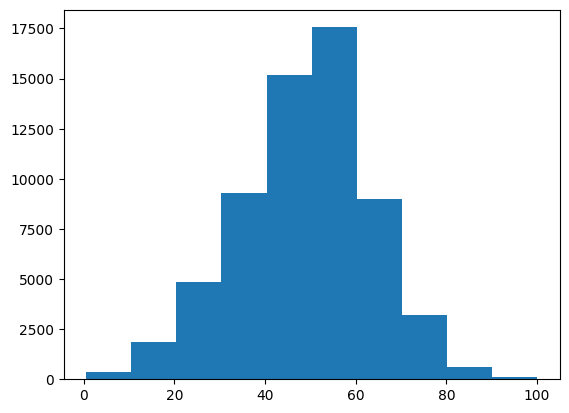

In [48]:
# Visualizamos un histograma de metascore para la tendencia y ver si fue un procedimiento adecuado
metascore=MoviesCopy['metascore'].dropna()
plt.hist(metascore)
plt.show

# Rating

Unificamos la información de la columna **rating**

In [49]:
# Se usa el metodo .astype(str) para poder realizar la unificación
MoviesCopy['rating'] = MoviesCopy['rating'].astype(str).apply(lambda x: x.replace('Not Rated', 'Unrated'))
MoviesCopy['rating'] = MoviesCopy['rating'].astype(str).apply(lambda x: x.replace('Passed', 'Approved'))
MoviesCopy['rating'] = MoviesCopy['rating'].astype(str).apply(lambda x: x.replace('All', 'G/TV-G'))
MoviesCopy['rating'] = MoviesCopy['rating'].astype(str).apply(lambda x: x.replace('Open', 'G/TV-G'))
MoviesCopy['rating'] = MoviesCopy['rating'].astype(str).apply(lambda x: x.replace('(Banned)', 'X'))
MoviesCopy['rating'] = MoviesCopy['rating'].astype(str).apply(lambda x: x.replace('U', 'G/TV-G'))

# Por errores desconocidos en la unificación volvemos a corregir los mismos
MoviesCopy['rating'] = MoviesCopy['rating'].astype(str).apply(lambda x: x.replace('G/TV-Gnrated', 'G/TV-G'))
MoviesCopy['rating'] = MoviesCopy['rating'].astype(str).apply(lambda x: x.replace('G/TV-GA', 'G/TV-G'))

MoviesCopy['rating'].unique()

array(['PG-13', '18', 'R', 'G', 'PG', 'nan', 'TV-MA', 'G/TV-G',
       'Approved', 'TV-14', 'GP', 'TV-PG', 'M', 'X', 'TV-G', 'NC-17',
       'M/PG', 'TV-Y', 'C', 'TV-Y7', 'AO', 'E', 'A', 'TV-13'],
      dtype=object)

## Outliers

# Tratamos los valores atípicos o outliers de la columna **runtime**

In [50]:
# Usamos el método quantile() para obtener los cuartiles 1 (25%) y 3 (75%)
Q1 = MoviesCopy['runtime(min)'].quantile(0.25)
Q3 = MoviesCopy['runtime(min)'].quantile(0.75)

# Calculamos el rango intercuartil
IQR = Q3 - Q1

# Define los límites para identificar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
limite_sup=200

# Identifica los outliers
outliers = MoviesCopy[(MoviesCopy['runtime(min)'] < limite_inferior) | (MoviesCopy['runtime(min)'] > limite_superior)]
outliers2 =MoviesCopy[(MoviesCopy['runtime(min)'])> limite_sup]
outliers2

,title,rating,year,users_rating,votes,metascore,img_url,countries,languages,actors,genre,tagline,description,directors,runtime(min),imdb_url
1574,River of Fundament,nan,2014.0,7.1,157.0,56.000000,https://m.media-amazon.com/images/M/MV5BNDRhN2...,['USA'],"['English', 'Spanish']","['Dave Bald Eagle', 'Milford Graves', 'John Bu...",['Drama'],NaN,"In 2007, Matthew Barney and Jonathan Bepler be...",['Matthew Barney'],319.0,https://www.imdb.com/title/tt3529612/
2172,The Phantom Creeps,Approved,1939.0,4.7,802.0,37.518572,https://m.media-amazon.com/images/M/MV5BZTQ4MG...,['USA'],['English'],"['Bela Lugosi', 'Robert Kent', 'Dorothy Arnold...","['Action', 'Horror', 'Sci-Fi']",CRASHING...SMASHING...DASHING DYNAMITE! 12 spi...,A military intelligence officer and a pretty r...,"['Ford Beebe', 'Saul A. Goodkind']",265.0,https://www.imdb.com/title/tt0031796/
2239,Dick Tracy,Approved,1937.0,6.7,538.0,57.518572,https://m.media-amazon.com/images/M/MV5BMmZkZm...,['USA'],['English'],"['Ralph Byrd', 'Kay Hughes', 'Smiley Burnette'...","['Action', 'Comedy', 'Crime', 'Thriller']",ACE G-MAN --- WAGING A ONE-MAN WAR ON CRIME! (...,A master criminal called The Spider puts the f...,"['Alan James', 'Ray Taylor']",290.0,https://www.imdb.com/title/tt0028785/
2328,The Shadow of the Eagle,Approved,1932.0,5.8,321.0,48.518572,https://m.media-amazon.com/images/M/MV5BNDViYW...,['USA'],['English'],"['John Wayne', 'Dorothy Gulliver', 'Walter Mil...","['Crime', 'Drama', 'Mystery', 'Thriller']",A CRASHING Adventure Serial! (1949 re-release ...,The Eagle uses sky writing to make threats aga...,"['Ford Beebe', 'B. Reeves Eason']",218.0,https://www.imdb.com/title/tt0023456/
2906,The Hurricane Express,Approved,1932.0,5.4,488.0,44.518572,https://m.media-amazon.com/images/M/MV5BMTg5OT...,['USA'],['English'],"['John Wayne', 'Shirley Grey', 'Conway Tearle'...","['Action', 'Adventure', 'Crime', 'Drama', 'Mys...",A THRILLER of the ROARING RAILS In Twelve Cras...,"When his father is killed in a train wreck, La...","['J.P. McGowan', 'Armand Schaefer']",227.0,https://www.imdb.com/title/tt0023038/
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60854,Rooster Teeth: Best of RT Shorts and Animated ...,G/TV-G,2013.0,8.5,85.0,75.518572,https://m.media-amazon.com/images/M/MV5BZjliN2...,['USA'],['English'],"['Burnie Burns', 'Gavin Free', 'Joel Heyman', ...",['Comedy'],NaN,"You've watched hilarious films before, but you...","['Chris Demarais', 'Brandon Farmahini', '2 mor...",233.0,https://www.imdb.com/title/tt3462466/
60911,Heroes of the West,Approved,1932.0,5.7,25.0,47.518572,https://m.media-amazon.com/images/M/MV5BMzJhZT...,['USA'],['English'],"['Onslow Stevens', 'Julie Bishop', 'Noah Beery...","['Action', 'Adventure', 'Mystery', 'Romance', ...",NaN,Efforts to build a transcontinental railroad a...,['Ray Taylor'],225.0,https://www.imdb.com/title/tt0023000/
61405,Perils of the Wild,nan,1925.0,5.4,14.0,44.518572,https://m.media-amazon.com/images/M/MV5BNjVlZD...,['USA'],['English'],"['Joe Bonomo', 'Margaret Quimby', 'Jack Mower'...",['Adventure'],NaN,NaN,['Francis Ford'],300.0,https://www.imdb.com/title/tt0016214/
61576,Who Pays?,nan,1915.0,6.8,15.0,58.518572,https://m.media-amazon.com/images/M/MV5BY2NhOT...,['USA'],['English'],"['Henry King', 'Ruth Roland', 'Ed Brady', 'Dan...",['Drama'],NaN,Who Pays? (1915) was a series of twelve three-...,"['Harry Harvey', 'H.M. Horkheimer', '1 more cr...",360.0,https://www.imdb.com/title/tt0006283/


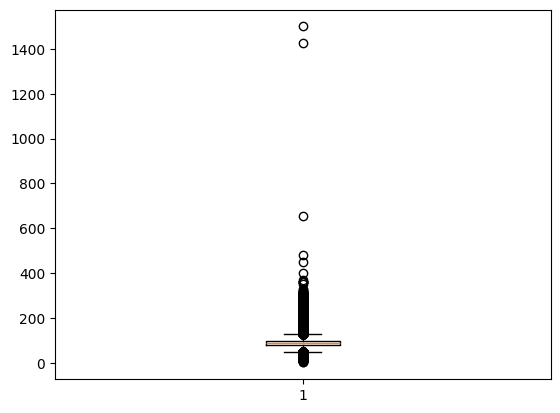

In [51]:
plt.boxplot(runtime)
plt.show()

Pudimos observar que al ser películas y series el tiempo en runtime puede ser muy variado, por lo que pueden tener mas de 200 minutos, entonces dejamos los datos sin modificar

## Analisis extra de valores nulos

Ya no se pueden hacer mas tecnicas de imputación de los datos ya que sería sesgar la información, por lo que identificamos como desconocido o 'Unknown' a los valores nulos de las columnas **rating**, **img_url**, **tagline**, **description**, **directors**.

In [52]:
# Usamos el método fillna() para reemplazar los valores nulos de las colmnas restantes.
MoviesCopy.fillna({ 'rating': 'Unknown' }, inplace=True)
MoviesCopy.fillna({ 'img_url': 'Unknown' }, inplace=True)
MoviesCopy.fillna({ 'tagline': 'Unknown' }, inplace=True)
MoviesCopy.fillna({ 'description': 'Unknown' }, inplace=True)
MoviesCopy.fillna({ 'directors': 'Unknown' }, inplace=True)

# Verificamos el número total de valores nulos.
MoviesCopy.isna().sum()

title           0
rating          0
year            0
users_rating    0
votes           0
metascore       0
img_url         0
countries       0
languages       0
actors          0
genre           0
tagline         0
description     0
directors       0
runtime(min)    0
imdb_url        0
dtype: int64

- Podemos concluir que no hay mas outliers y datos nulos, por lo que la limpieza de los datos la damos por finalizada.

- Procedemos a exportar el dataset de MoviesCopy

In [53]:
# Usamos el método to_csv() para exportar el dataset.
MoviesCopy.to_csv('Dataset_IMDb_cleaned.csv', index=False)